# Bit-Plane Decomposition



**เป้าหมายการเรียนรู้**

- เข้าใจว่า pixel 8-bit เกิดจาก bit 8 ตำแหน่ง
- แยกภาพออกเป็น bit plane ตั้งแต่ bit 0 ถึง bit 7 ได้
- อธิบายได้ว่า bit ต่ำและ bit สูงมีผลต่อภาพต่างกันอย่างไร
- รวม bit plane บางส่วนกลับเป็นภาพเพื่อดูผลของการเก็บเฉพาะ bit สำคัญได้


## หลักการ

ภาพ grayscale แบบ 8-bit มีค่า pixel ตั้งแต่ 0 ถึง 255 ซึ่งเขียนในรูปเลขฐานสองได้ 8 bit

$$
p = b_7 2^7 + b_6 2^6 + b_5 2^5 + b_4 2^4 + b_3 2^3 + b_2 2^2 + b_1 2^1 + b_0 2^0
$$

โดย

- $p$ คือค่า pixel หนึ่งตำแหน่ง
- $b_0$ คือ bit ต่ำสุด หรือ least significant bit (LSB)
- $b_7$ คือ bit สูงสุด หรือ most significant bit (MSB)
- แต่ละ $b_k$ มีค่าเป็น 0 หรือ 1 เท่านั้น

การทำ bit-plane decomposition คือการแยกภาพออกเป็นภาพขาวดำ 8 ภาพ แต่ละภาพแสดงว่า bit ตำแหน่งนั้นของแต่ละ pixel เป็น 0 หรือ 1

**แนวคิดสำคัญ**

- bit ต่ำ เช่น bit 0-2 มักมีรายละเอียดเล็ก ๆ หรือ noise มาก
- bit สูง เช่น bit 5-7 มักเก็บโครงสร้างหลักของภาพ
- การรวมเฉพาะ bit สูงสามารถให้ภาพที่ยังเห็นรายละเอียดหลัก แต่ใช้ข้อมูลน้อยลง


## 1) เตรียมเครื่องมือ

ใช้ `cv2.imread()` อ่านภาพเป็น grayscale และใช้ `matplotlib.pyplot` สำหรับแสดงผลใน notebook


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "./images/mandril_color.tif"


## 2) อ่านภาพระดับเทา

ถึงแม้ไฟล์ต้นฉบับจะเป็นภาพสี แต่ในตัวอย่างนี้อ่านเป็น grayscale โดยกำหนด `cv2.IMREAD_GRAYSCALE`


In [2]:
img = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError(f"Cannot read image: {IMAGE_PATH}")

print(f"shape   : {img.shape}")
print(f"dtype   : {img.dtype}")
print(f"min/max : {img.min()} / {img.max()}")


shape   : (512, 512)
dtype   : uint8
min/max : 1 / 200


## 3) แสดงภาพต้นฉบับ

กำหนด `cmap="gray"` เพื่อแสดงภาพระดับเทา และกำหนด `vmin=0, vmax=255` เพื่อให้ช่วงสีตรงกับภาพ 8-bit


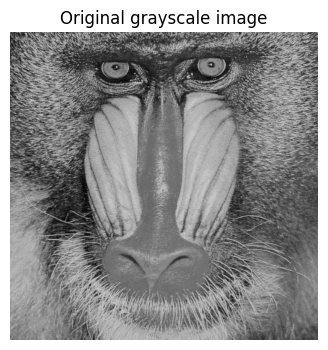

In [3]:
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original grayscale image")
plt.axis("off")
plt.show()


## 4) แยก Bit Plane

ใช้แนวคิดต่อไปนี้กับแต่ละ pixel

1. เลื่อน bit ที่ต้องการมาไว้ตำแหน่งขวาสุดด้วย `>> bit`
2. ใช้ `& 1` เพื่อดึงเฉพาะ bit นั้น
3. คูณด้วย 255 เพื่อให้แสดงผลเป็นภาพขาวดำชัดเจน

ตัวอย่างเช่น bit plane ที่ได้จะมีค่า 0 หรือ 255 สำหรับการแสดงผล แต่ความหมายจริงคือ bit นั้นเป็น 0 หรือ 1


In [4]:
bit_planes = []

for bit in range(8):
    plane = (img >> bit) & 1
    plane = (plane * 255).astype(np.uint8)
    bit_planes.append(plane)


## 5) แสดงผล Bit Plane ทั้ง 8 ระดับ

bit 0 คือ LSB มีน้ำหนักน้อยที่สุด ส่วน bit 7 คือ MSB มีน้ำหนักมากที่สุด


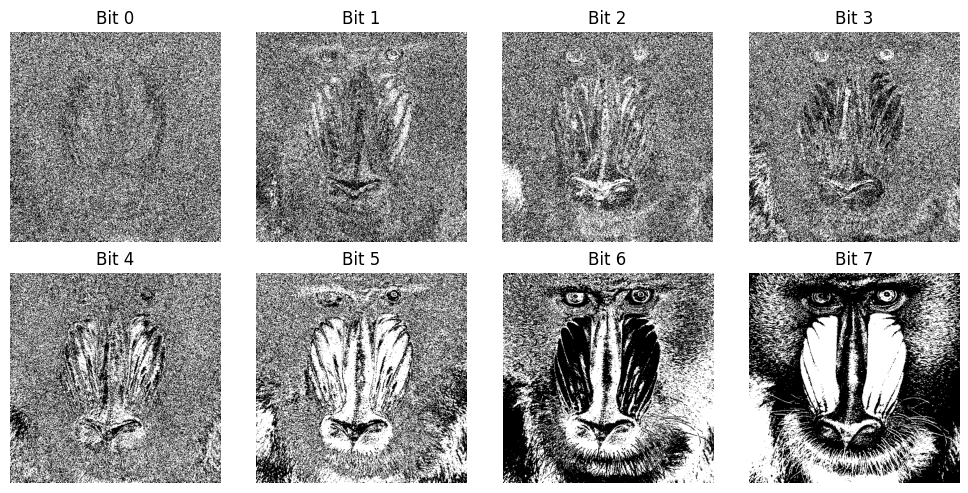

In [5]:
plt.figure(figsize=(10, 5))

for bit in range(8):
    plt.subplot(2, 4, bit + 1)
    plt.imshow(bit_planes[bit], cmap="gray", vmin=0, vmax=255)
    plt.title(f"Bit {bit}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 6) เปรียบเทียบภาพต้นฉบับกับ Bit สำคัญ

ถ้าต้องการเก็บเฉพาะโครงสร้างหลักของภาพ สามารถรวมเฉพาะ bit สูง เช่น bit 4 ถึง bit 7 กลับเป็นภาพใหม่ได้

ภาพที่สร้างจาก bit 4-7 จะสูญเสียรายละเอียดบางส่วนจาก bit ต่ำ แต่ยังรักษารูปร่างและความสว่างหลักไว้ได้


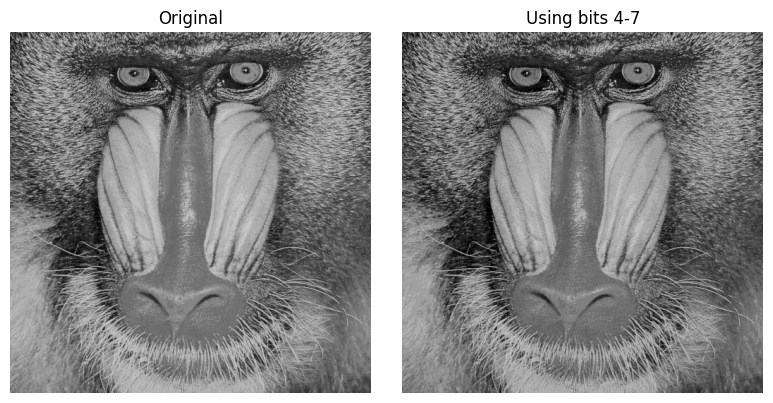

In [8]:
high_bit_img = np.zeros_like(img)

for bit in range(4, 8):
    high_bit_img += (((img >> bit) & 1) * (2 ** bit)).astype(np.uint8)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(high_bit_img, cmap="gray", vmin=0, vmax=255)
plt.title("Using bits 4-7")
plt.axis("off")

plt.tight_layout()
plt.show()


## 7) ตรวจสอบการรวม Bit Plane ทั้งหมด

ถ้ารวม bit 0 ถึง bit 7 ด้วยน้ำหนักเดิมทั้งหมด จะต้องได้ภาพเดิมกลับมา

$$
p = \sum_{k=0}^{7} b_k 2^k
$$

ขั้นตอนนี้ช่วยยืนยันว่า bit-plane decomposition ไม่ได้ทำข้อมูลหาย หากเก็บครบทุก bit


In [ ]:
reconstructed = np.zeros_like(img)

for bit in range(8):
    reconstructed += (((img >> bit) & 1) * (2 ** bit)).astype(np.uint8)

print("Reconstruction equals original:", np.array_equal(img, reconstructed))


## สรุป

Bit-plane decomposition เป็นการมองภาพ 8-bit แยกตามตำแหน่ง bit ของแต่ละ pixel ทำให้เห็นว่าแต่ละ bit มีบทบาทต่อภาพไม่เท่ากัน โดย bit สูงมักเก็บโครงสร้างหลัก ส่วน bit ต่ำมักเป็นรายละเอียดเล็กหรือ noise

**คำถามสำหรับผู้เรียน**

1. bit plane ใดเห็นโครงสร้างของภาพชัดที่สุด
2. ถ้าใช้เฉพาะ bit 6-7 ภาพยังพอดูรู้เรื่องหรือไม่
3. ถ้าต้องการลดขนาดข้อมูลของภาพ ควรเก็บ bit ต่ำหรือ bit สูง เพราะอะไร
